# HDT 6: Boosting e Inferencia Causal

**Ciencia de Datos, Sección A** · Asignada: martes 6 de octubre · **Entrega: martes 13 de octubre, 23:59**

**Nombre:** _Victor Saravia_
**Carné no.:** _20240060_

Completar las celdas marcadas con `# ¿Qué va aquí?`. Cada ejercicio incluye una verificación comentada: descomentar para comprobar el resultado. Antes de entregar: **Kernel → Restart & Run All** (un notebook que no corre de arriba a abajo pierde 0.5 pts).

AI: resolver sin AI. Si se usó para entender un concepto, anotarlo en la bitácora del final (no penaliza).

## Setup

Dependencias: `pip install numpy pandas matplotlib scikit-learn`. Todo es determinista (semillas fijas y splits fijos): las verificaciones son exactas.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

AZUL, ROJO, GRIS, LINEA = "#3A6EA5", "#B04A2E", "#75808E", "#E0E4EA"

def eje_limpio(ax):
    ax.grid(color=LINEA, lw=0.6, alpha=0.7)
    ax.spines[["top", "right"]].set_visible(False)

## Los datos

Dos historias, dos datasets:

**Repartos** (partes A y B): una repartidora quiere predecir cuántos `minutos` toma cada entrega, con `distancia` (km) y `paquetes`. Es el mismo tipo de problema que las tiendas de la sesión 18.

**Socios y el curso de finanzas** (parte C): el banco ofrece un curso de finanzas personales y observa que quienes lo tomaron pagan más puntual. ¿El curso causa la puntualidad? El mismo tipo de trampa que la app de la sesión 19.

Las celdas generan los datos completas; no hay nada que llenar aquí.

In [2]:
from sklearn.model_selection import train_test_split

rng = np.random.default_rng(6)
m = 350
distancia = rng.uniform(1, 20, m).round(1)
paquetes = rng.integers(1, 9, m)
minutos = (12 + 2.6 * distancia + 3.5 * paquetes + 0.15 * distancia * paquetes
           + rng.normal(0, 6, m)).round(1)
repartos = pd.DataFrame({"distancia": distancia, "paquetes": paquetes, "minutos": minutos})

R_train, R_test = train_test_split(repartos, test_size=0.3, random_state=1)
Xr, yr = R_train[["distancia", "paquetes"]], R_train["minutos"]
Xr_test, yr_test = R_test[["distancia", "paquetes"]], R_test["minutos"]
print("repartos:", len(R_train), "entrenamiento |", len(R_test), "prueba",
      "| promedio del entrenamiento:", round(yr.mean(), 1), "min")

rng_c = np.random.default_rng(60)
n = 2000
antiguedad = rng_c.integers(0, 20, n)
curso = (rng_c.random(n) < 1 / (1 + np.exp(-(antiguedad - 10) / 3))).astype(int)
puntual = (rng_c.random(n) < 1 / (1 + np.exp(-(-0.3 + (antiguedad - 10) / 4)))).astype(int)
socios = pd.DataFrame({"antiguedad": antiguedad, "curso": curso, "puntual": puntual})
print("socios:", len(socios), "| tomaron el curso:", socios["curso"].mean().round(2),
      "| pagan puntual:", socios["puntual"].mean().round(2))

repartos: 245 entrenamiento | 105 prueba | promedio del entrenamiento: 62.6 min
socios: 2000 | tomaron el curso: 0.48 | pagan puntual: 0.42


## Parte A · Boosting: árboles en fila (0.5 pt)

La sesión 18 con otra flota: cada árbol aprende lo que al anterior le faltó, y se agrega una fracción de su corrección.

### Ejercicio 1 (0.20): el paso 0 y el primer árbol

(a) El paso 0: predecir el promedio del entrenamiento para todos. ¿Cuál es el error absoluto promedio en prueba de ese modelo? (b) Entrenar un `DecisionTreeRegressor(max_depth=2, random_state=0)` sobre **lo que falta** (`yr - promedio`). (c) Armar la tabla de los primeros 3 repartos de prueba: minutos reales, predicción del paso 0, lo que falta, lo que agrega el árbol (la mitad de su corrección: paso 0.5) y la nueva predicción.

In [18]:
from sklearn.tree import DecisionTreeRegressor

promedio = yr.mean()
error_promedio = np.mean(np.abs(yr_test - promedio))

arbol1 = DecisionTreeRegressor(max_depth=2, random_state=0)
arbol1.fit(Xr, yr - promedio)

tabla = R_test.head(3).copy()
tabla["pred0"] = round(promedio, 1)
tabla["falta"] = tabla["minutos"] - tabla["pred0"]
tabla["agrega"] = 0.5 * arbol1.predict(tabla[["distancia", "paquetes"]])
tabla["nueva"] = tabla["pred0"] + tabla["agrega"]
print("Error absoluto promedio del paso 0:", round(error_promedio, 1))
print(tabla)


# Verificación (descomentar):
assert round(error_promedio, 1) == 19.7
assert round(tabla["agrega"].iloc[1], 1) == 15.2
assert round(tabla["nueva"].iloc[1], 1) == 77.8


Error absoluto promedio del paso 0: 19.7
     distancia  paquetes  minutos  pred0  falta     agrega      nueva
192       10.6         4     49.8   62.6  -12.8  -2.574082  60.025918
256       14.8         5     85.3   62.6   22.7  15.245009  77.845009
169       12.8         4     67.1   62.6    4.5   2.553756  65.153756


### Ejercicio 2 (0.15): la fila completa

Completar `boosting_a_mano`: en cada vuelta, entrenar un árbol de profundidad 2 sobre lo que falta, sumar `paso` veces su corrección a las predicciones (de entrenamiento y de prueba) y guardar el error de prueba. Correrla con 8 árboles y paso 0.5.

In [19]:
def boosting_a_mano(X, y, X_nuevo, y_nuevo, n_arboles, paso):
    pred = np.full(len(y), y.mean())
    pred_nuevo = np.full(len(y_nuevo), y.mean())
    errores = []
    for _ in range(n_arboles):
        # 1) árbol sobre lo que falta; 2) agregar una fracción de su corrección
        arbol = DecisionTreeRegressor(max_depth=2, random_state=0)
        arbol.fit(X, y - pred)
        pred += paso * arbol.predict(X)
        pred_nuevo += paso * arbol.predict(X_nuevo)
        errores.append(np.mean(np.abs(y_nuevo - pred_nuevo)))
    return errores

errores = boosting_a_mano(Xr, yr, Xr_test, yr_test, n_arboles=8, paso=0.5)
print("Errores en prueba:", [round(error, 1) for error in errores])

# Verificación (descomentar):
assert round(errores[0], 1) == 12.7
assert round(errores[-1], 1) == 5.7


Errores en prueba: [np.float64(12.7), np.float64(9.7), np.float64(7.4), np.float64(6.6), np.float64(6.2), np.float64(6.0), np.float64(5.8), np.float64(5.7)]


### Ejercicio 3 (0.15): qué tanto corregir en cada paso

Correr `boosting_a_mano` con 8 árboles y pasos 0.1, 0.5 y 1.0. Graficar las tres curvas de error (una línea por paso) y responder en un comentario: ¿cuál termina mejor, y qué le pasa a cada extremo?

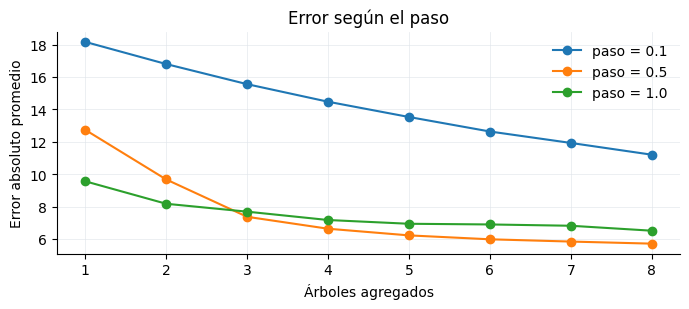

In [20]:
finales = {}
pasos = [0.1, 0.5, 1.0]
fig, ax = plt.subplots(figsize=(7, 3.2))
for paso in pasos:
    errores_paso = boosting_a_mano(Xr, yr, Xr_test, yr_test, n_arboles=8, paso=paso)
    ax.plot(range(1, 9), errores_paso, marker="o", label=f"paso = {paso}")
    finales[paso] = errores_paso[-1]
ax.set(xlabel="Árboles agregados", ylabel="Error absoluto promedio", title="Error según el paso")
ax.legend(frameon=False)
eje_limpio(ax)
plt.tight_layout()
plt.show()

# Respuesta: el paso 0.5 termina con menor error; 0.1 corrige lento y 1.0 da pasos grandes y puede pasarse.

# Verificación (descomentar):
assert round(finales[0.1], 1) == 11.2
assert round(finales[0.5], 1) == 5.7
assert round(finales[1.0], 1) == 6.5


## Parte B · ¿Bosque o boosting? (0.3 pt)

### Ejercicio 4 (0.15): los tres sobre la misma prueba

Comparar el error absoluto promedio en prueba de: el promedio a secas, un `RandomForestRegressor` (300 árboles, `random_state=0`) y un `HistGradientBoostingRegressor` (`random_state=0`).

In [21]:
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor

bosque = RandomForestRegressor(n_estimators=300, random_state=0)
bosque.fit(Xr, yr)
error_bosque = np.mean(np.abs(yr_test - bosque.predict(Xr_test)))

boosting = HistGradientBoostingRegressor(random_state=0)
boosting.fit(Xr, yr)
error_boosting = np.mean(np.abs(yr_test - boosting.predict(Xr_test)))

print("Promedio:", round(error_promedio, 1))
print("bosque:", round(error_bosque, 1)) 
print("boosting:", round(error_boosting, 1))

# Verificación (descomentar):
assert round(error_bosque, 1) == 5.4
assert round(error_boosting, 1) == 5.3


Promedio: 19.7
bosque: 5.4
boosting: 5.3


### Ejercicio 5 (0.15): parar a tiempo

Entrenar `HistGradientBoostingRegressor(max_iter=500, early_stopping=True, validation_fraction=0.15, random_state=0)`. ¿En cuántos árboles se detuvo (`n_iter_`) de los 500 permitidos? ¿Su error en prueba empeoró respecto al ejercicio 4?

In [7]:
temprano = HistGradientBoostingRegressor(
    max_iter=500, early_stopping=True, validation_fraction=0.15, random_state=0
)
temprano.fit(Xr, yr)
arboles_usados = temprano.n_iter_
error_temprano = np.mean(np.abs(yr_test - temprano.predict(Xr_test)))

print("Árboles usados:", arboles_usados)
print("Error en prueba:", round(error_temprano, 1))

# Verificación (descomentar):
# assert arboles_usados == 46
# assert round(error_temprano, 1) == 5.6


Árboles usados: 46
Error en prueba: 5.6


## Parte C · Inferencia causal (1.0 pt)

La sesión 19 con el curso de finanzas: predecir no es intervenir, y la diferencia cruda casi nunca es el efecto.

### Ejercicio 6 (0.20): la diferencia cruda

La tasa de pago puntual de quienes tomaron el curso contra quienes no. Calcular ambas (en %) y la diferencia. Es el número que el gerente quiere presentar; guardarlo para compararlo después.

In [8]:
tasas = socios.groupby("curso")["puntual"].mean() * 100
dif_cruda = tasas.loc[1] - tasas.loc[0]

print("Tasas puntuales por curso (%):")
print(tasas)
print("Diferencia cruda (puntos porcentuales):", round(dif_cruda, 1))

# Verificación (descomentar):
# assert round(dif_cruda, 1) == 35.4


Tasas puntuales por curso (%):
curso
0    25.289575
1    60.684647
Name: puntual, dtype: float64
Diferencia cruda (puntos porcentuales): 35.4


### Ejercicio 7 (0.20): comparar dentro de grupos parecidos

Cortar `antiguedad` en tres niveles con `pd.cut(socios["antiguedad"], [-1, 6, 13, 19], labels=["nuevo", "medio", "veterano"])`. Para cada nivel: la tasa puntual con y sin curso, y su diferencia. Reportar el promedio de las tres diferencias y compararlo con la cruda.

In [22]:
socios["nivel"] = pd.cut(socios["antiguedad"], [-1, 6, 13, 19],
                         labels=["nuevo", "medio", "veterano"])

por_nivel = socios.groupby(["nivel", "curso"], observed=False)["puntual"].mean().unstack() * 100
dif_por_nivel = por_nivel[1] - por_nivel[0]
dif_promedio = dif_por_nivel.mean()

print("Tasa puntual por nivel y curso (%):")
print(por_nivel)
print("Diferencia por nivel (puntos porcentuales):")
print(dif_por_nivel)
print("Promedio de las diferencias:", round(dif_promedio, 1))

# Verificación (descomentar):
assert round(dif_por_nivel["medio"], 1) == 0.1
assert round(dif_promedio, 1) == 4.4


Tasa puntual por nivel y curso (%):
curso             0          1
nivel                         
nuevo     12.153846  20.731707
medio     42.461538  42.521994
veterano  73.770492  78.188540
Diferencia por nivel (puntos porcentuales):
nivel
nuevo       8.577861
medio       0.060456
veterano    4.418048
dtype: float64
Promedio de las diferencias: 4.4


### Ejercicio 8 (0.20): la paradoja de Simpson

Un programa de tutorías, dos cursos. Calcular la tasa de aprobados por fila, y luego la tasa total de cada grupo (con y sin tutor) juntando los dos cursos. ¿Qué se invierte? ¿A cuál número hay que creerle y por qué?

In [10]:
tutorias = pd.DataFrame({
    "curso": ["Cálculo", "Cálculo", "Álgebra", "Álgebra"],
    "tutor": ["no", "sí", "no", "sí"],
    "estudiantes": [300, 100, 100, 300],
    "aprobaron": [255, 92, 60, 207],
})

tutorias["tasa"] = tutorias["aprobaron"] / tutorias["estudiantes"] * 100
total = tutorias.groupby("tutor")[["estudiantes", "aprobaron"]].sum()
total["tasa"] = total["aprobaron"] / total["estudiantes"] * 100
print("Tasa por curso y tutor:")
print(tutorias)
print("Tasa total por tutor:")
print(total)
# Respuesta: en cada curso, quienes recibieron tutoría aprueban más, pero al juntar los cursos la tasa total se invierte por la distinta distribución de estudiantes.

# Verificación (descomentar):
# assert tutorias["tasa"].tolist() == [85.0, 92.0, 60.0, 69.0]
# assert round(total.loc["sí", "tasa"], 2) == 74.75 and round(total.loc["no", "tasa"], 2) == 78.75


Tasa por curso y tutor:
     curso tutor  estudiantes  aprobaron  tasa
0  Cálculo    no          300        255  85.0
1  Cálculo    sí          100         92  92.0
2  Álgebra    no          100         60  60.0
3  Álgebra    sí          300        207  69.0
Tasa total por tutor:
       estudiantes  aprobaron   tasa
tutor                               
no             400        315  78.75
sí             400        299  74.75


### Ejercicio 9 (0.20): importante para predecir no es causa

Dos logísticas para predecir `puntual`: el modelo A solo con `curso`; el modelo B con `curso` y `antiguedad`. Comparar el coeficiente de `curso` en cada una. ¿Qué le pasa cuando la causa real entra al modelo?

In [11]:
from sklearn.linear_model import LogisticRegression

modelo_a = LogisticRegression().fit(socios[["curso"]], socios["puntual"])
modelo_b = LogisticRegression().fit(socios[["curso", "antiguedad"]], socios["puntual"])

coef_curso_a = modelo_a.coef_[0][0]
coef_curso_b = modelo_b.coef_[0][0]

print("Coeficiente de curso, modelo A:", round(coef_curso_a, 2))
print("Coeficiente de curso, modelo B:", round(coef_curso_b, 2))
print("Coeficiente de antigüedad en B:", round(modelo_b.coef_[0][1], 2))
# Respuesta: al controlar por antigüedad, el coeficiente del curso cae casi a cero; la asociación predictiva cruda no mide un efecto causal.

# Verificación (descomentar):
# assert round(coef_curso_a, 2) == 1.5
# assert round(coef_curso_b, 2) == -0.08


Coeficiente de curso, modelo A: 1.5
Coeficiente de curso, modelo B: -0.08
Coeficiente de antigüedad en B: 0.24


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: overflow encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: invalid value encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Library/Frameworks/Python.framework/Versions/3.13/

### Ejercicio 10 (0.20): el colisionador, con dos monedas

Tirar dos monedas independientes 4,000 veces (`np.random.default_rng(61).integers(0, 2, 4000)` para cada una, en ese orden). (a) Su correlación: debe ser ~0. (b) Filtrar solo las tiradas donde salió al menos una cara y recalcular la correlación entre las que pasaron el filtro. ¿Qué apareció?

In [12]:
rng_m = np.random.default_rng(61)
moneda1 = rng_m.integers(0, 2, 4000)
moneda2 = rng_m.integers(0, 2, 4000)

corr_sin_filtro = np.corrcoef(moneda1, moneda2)[0, 1]
pasan = (moneda1 == 1) | (moneda2 == 1)
corr_filtrada = np.corrcoef(moneda1[pasan], moneda2[pasan])[0, 1]

print("Correlación sin filtro:", round(corr_sin_filtro, 3))
print("Correlación al filtrar por al menos una cara:", round(corr_filtrada, 2))
# Respuesta: el filtro crea una correlación negativa entre monedas que originalmente eran independientes; condicionar en el colisionador (al menos una cara) induce esa asociación.

# Verificación (descomentar):
# assert abs(corr_sin_filtro) < 0.05
# assert round(corr_filtrada, 2) == -0.49


Correlación sin filtro: 0.023
Correlación al filtrar por al menos una cara: -0.49


## Parte D · Criterio (0.2 pt)

### Ejercicio 11 (0.20)

Dos preguntas, 2-3 líneas cada una, **citando los números obtenidos**:

**(a)** El gerente propone: "los del curso pagan 35 puntos mejor; hagámoslo obligatorio y la puntualidad sube 35 puntos". Con los ejercicios 6, 7 y 9, explicar qué está mal y qué subida es realista esperar.

**(b)** ¿Qué tendría que hacer el banco para medir el efecto REAL del curso? Describir el diseño en 2-3 líneas y explicar por qué resuelve el problema que los datos observados no pueden resolver.

_(Responder editando esta celda)_

**Respuesta (a):** La diferencia fue 35.4 puntos, pero al comparar socios con antigüedad parecida el promedio bajó a 4.4. Además, el coeficiente del curso pasó de 1.5 a −0.08. Por eso no se puede prometer que obligar a tomar el curso aumentará los pagos puntuales, pues la diferencia grande se explica sobre todo por la antigüedad. 

**Respuesta (b):** El banco puede hacer un sorteo: un grupo toma el curso ahora y otro después. Como el azar reparte de manera más justa las diferencias entre las personas, comparar sus pagos puntuales ayuda a saber si el curso realmente hizo una diferencia y permite medir mejor el efecto.

## Bitácora de AI (opcional, no penaliza)

Si se usó AI para entender algún concepto, anotar aquí qué se preguntó y qué se entendió. Si no se usó, escribir "No se usó".

- Esta vez sí usé AI como apoyo para completar el código, porque aún no habían subido los notebooks de esos temas ni las presentaciones de boosting e inferencia causal, y después revisé los resultados con las verificaciones incluidas.
